# 02 Environmental Context
**Project:** Black Hills Mining Landscape Digital Twin Phase I
**Territory:** He Sapa (Black Hills) Unceded Lakota Territory
**Data Sources:** USGS WBD, USGS NHD, USGS 3DEP

## Purpose

Mining in He Sapa was not an abstraction. It happened on a specific
landscape, drained by specific watersheds, carved through specific
geology, with tailings and waste deposited adjacent to specific streams.

This notebook builds the environmental context layers:
- HUC-8 watershed boundaries showing which drainages received mining waste
- Stream network showing downstream contamination pathways
- Terrain showing how the landscape channeled runoff from mine sites

These layers frame every subsequent analysis in the twin.

## Why Watersheds Matter Here

The Cheyenne River, which drains much of the southern Black Hills,
flows northeast through the Pine Ridge and Cheyenne River Sioux
Reservations before reaching the Missouri River. Contamination
from He Sapa mining does not stop at the Black Hills boundary.
The watershed layer makes that downstream connection visible.

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path().resolve().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import warnings
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx

from src.constants import (
    CRS_GEOGRAPHIC, CRS_PROJECTED,
    BLACK_HILLS_BBOX, OUTPUTS_DIR, FIGURES_DIR,
)
from src.loaders import load_wbd, load_nhd_streams, load_black_hills_boundary
from src.sovereignty import print_data_acknowledgment, generate_citations

warnings.filterwarnings("ignore")
%matplotlib inline

def despine(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# Load gazetteer from notebook 01
gazetteer_path = OUTPUTS_DIR / "he_sapa_mine_gazetteer.geojson"
assert gazetteer_path.exists(), "Run notebook 01 first."
mines = gpd.read_file(gazetteer_path)
bh    = load_black_hills_boundary()
print(f"Mines loaded: {len(mines):,}")

AssertionError: Run notebook 01 first.

In [2]:
print_data_acknowledgment(source_keys=["wbd", "nhd", "3dep"])


BLACK HILLS MINING DIGITAL TWIN TREATY TERRITORY ACKNOWLEDGMENT

He Sapa (the Black Hills) is unceded Lakota territory.

The 1868 Fort Laramie Treaty guaranteed He Sapa and surrounding lands to the Lakota
and their allies in perpetuity. After Custer's 1874 expedition confirmed gold, 
the US Congress unilaterally took the Black Hills in 1877. The US Supreme
Court ruled this action as unconstitutional in United States v. Sioux Nation of
Indians, 448 U.S. 371 (1980). The Sioux Nations have declined
the offered compensation. The Black Hills are not for sale.

Every record in this system carries that context as a provenance field.

GOVERNANCE FRAMEWORKS:

OCAP®  : The Oceti Sakowin and allied Nations have Ownership, Control, Access,
  and Possession of data describing their territory and resources.
  Phase I uses public federal data only. Any results describing
  He Sapa should be shared with relevant Lakota governance bodies
  before external publication or distribution.
  Reference: http

## Watershed Boundaries

In [3]:
# Load HUC-8 watersheds intersecting He Sapa
huc8 = load_wbd(bbox=BLACK_HILLS_BBOX, huc_level=8)

print(f"HUC-8 watersheds: {len(huc8)}")
if not huc8.empty:
    huc_col = next((c for c in huc8.columns if c.startswith("huc") and c[-1].isdigit()), None)
    name_col = "name" if "name" in huc8.columns else None
    if name_col:
        print("\nWatershed names:")
        for name in huc8[name_col].tolist():
            print(f" {name}")

WBD HUC-8: 9 watersheds
HUC-8 watersheds: 9

Watershed names:
 Beaver
 Upper Cheyenne
 Angostura Reservoir
 Middle Cheyenne-Spring
 Rapid
 Middle Cheyenne-Elk
 Lower Belle Fourche
 Redwater
 Upper Belle Fourche


In [ ]:
# Mine count per watershed
if not huc8.empty:
    huc_proj   = huc8.to_crs(CRS_PROJECTED)
    mines_proj = mines.to_crs(CRS_PROJECTED)
    joined = gpd.sjoin(mines_proj, huc_proj, how="left", predicate="within")

    huc_id = next((c for c in huc8.columns if c.startswith("huc") and c[-1].isdigit()), None)
    if huc_id and huc_id in joined.columns:
        mine_counts = joined.groupby(f"{huc_id}_right").size().rename("mine_count")
        huc8 = huc8.merge(mine_counts, left_on=huc_id, right_index=True, how="left")
        huc8["mine_count"] = huc8["mine_count"].fillna(0).astype(int)
        print("Mines per watershed:")
        for _, row in huc8.sort_values("mine_count", ascending=False).iterrows():
            name = row.get("name", row.get(huc_id, "Unknown"))
            print(f"  {name}: {row['mine_count']:,} mines")

## Stream Network

In [4]:
streams = load_nhd_streams(bbox=BLACK_HILLS_BBOX, min_stream_order=2)

print(f"Stream segments: {len(streams):,}")

if not streams.empty and "gnis_name" in streams.columns:
    named = streams[streams["gnis_name"].notna() & (streams["gnis_name"] != "")]
    print(f"Named streams: {named['gnis_name'].nunique()}")
    print("\nMajor named streams:")
    for name in named["gnis_name"].value_counts().head(10).index:
        print(f"  {name}")

NHD streams (order >= 2): 1,639 segments
Stream segments: 1,639
Named streams: 151

Major named streams:
  Beaver Creek
  Spring Creek
  Alkali Creek
  Skull Creek
  South Beaver Creek
  Inyan Kara Creek
  Oil Creek
  Stockade Beaver Creek
  Mason Creek
  Dry Creek


## Environmental Context Map

NameError: name 'bh' is not defined

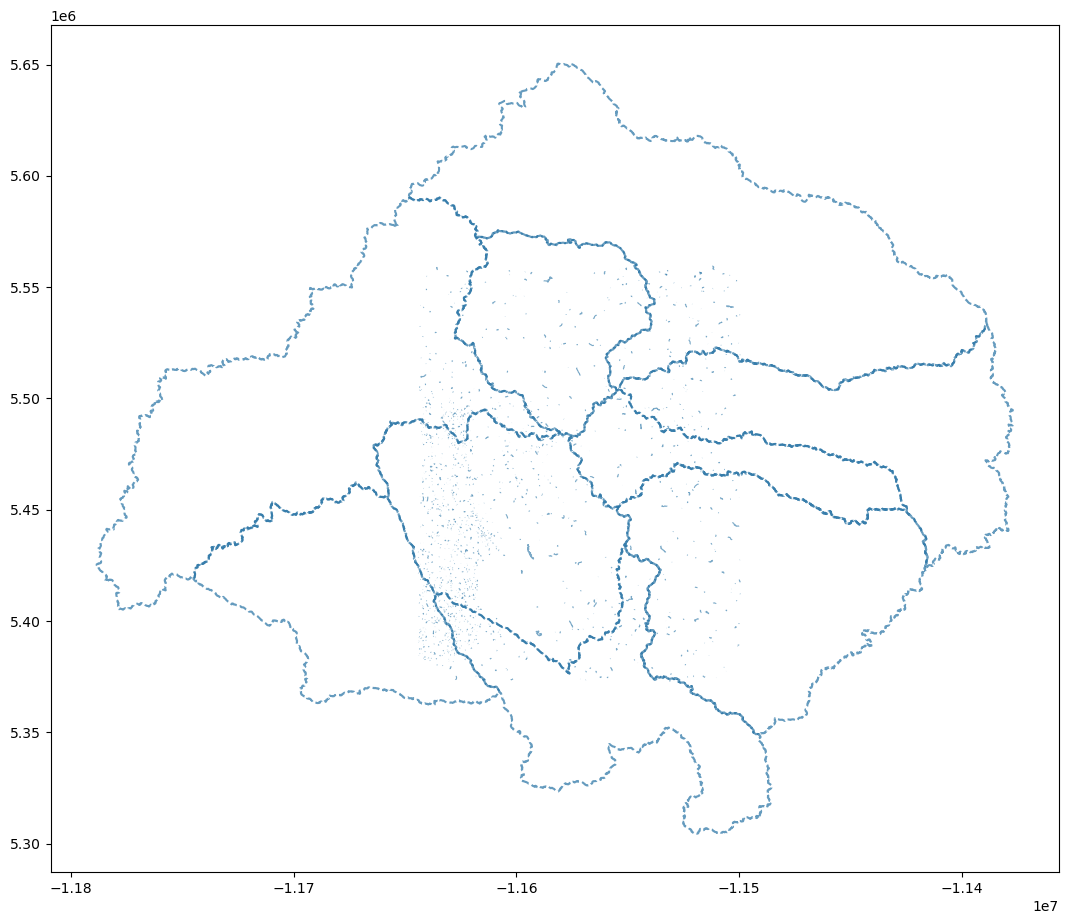

In [7]:
fig, ax = plt.subplots(figsize=(14, 11))

# Watersheds
if not huc8.empty:
    huc8.to_crs(3857).plot(
        ax=ax, facecolor="none", edgecolor="#2471A3",
        linewidth=1.5, linestyle="--", alpha=0.7, zorder=1,
    )

# Streams
if not streams.empty:
    streams.to_crs(3857).plot(
        ax=ax, color="#2471A3", linewidth=0.8, alpha=0.6, zorder=2,
    )

# Mines
'''
mines.to_crs(3857).plot(
    ax=ax, color="#E74C3C", markersize=12,
    alpha=0.6, zorder=3, label=f"Mine sites ({len(mines):,})",
)
'''
# Boundary
bh.to_crs(3857).plot(
    ax=ax, facecolor="none", edgecolor="#2C3E50",
    linewidth=2.5, linestyle="--", zorder=4,
)

try:
    ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, alpha=0.4)
except Exception:
    pass

ax.set_axis_off()

import matplotlib.lines as mlines
legend_elements = [
    mlines.Line2D([0],[0], color="#E74C3C", marker="o", linestyle="",
                  markersize=8, label=f"Mine sites ({len(mines):,})"),
    mlines.Line2D([0],[0], color="#2471A3", linewidth=1.5, label="Stream network (NHD)"),
    mlines.Line2D([0],[0], color="#2471A3", linewidth=1.5, linestyle="--",
                  label="HUC-8 watershed boundary"),
    mlines.Line2D([0],[0], color="#2C3E50", linewidth=2.5, linestyle="--",
                  label="He Sapa study area"),
]
ax.legend(handles=legend_elements, loc="lower left", fontsize=9, framealpha=0.9)
ax.set_title(
    "He Sapa (Black Hills) — Mining Sites and Environmental Context\n"
    "Watersheds, stream network, and mine locations | Unceded Lakota Territory",
    fontsize=12, fontweight="bold",
)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "02_environmental_context.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: figures/02_environmental_context.png")

## Export

In [ ]:
if not huc8.empty:
    huc8.to_file(OUTPUTS_DIR / "he_sapa_watersheds.geojson", driver="GeoJSON")
    print("Exported: outputs/he_sapa_watersheds.geojson")

if not streams.empty:
    streams.to_file(OUTPUTS_DIR / "he_sapa_streams.geojson", driver="GeoJSON")
    print("Exported: outputs/he_sapa_streams.geojson")

print()
print("NOTE: The Cheyenne River drains south and east from He Sapa")
print("through Pine Ridge and Cheyenne River Sioux Reservations.")
print("Mining contamination pathways extend well beyond this study area.")

In [ ]:
print(generate_citations(["wbd", "nhd", "3dep"]))